
# Property & Casualty Portfolio Mexico
## Objective
This notebook performs an exploratory data analysis of the Mexico P&C portfolio
with particular focus on the missing `industry` values.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [19]:
from pathlib import Path

DATA_PATH = Path("../data/raw/portfolio_mexico.csv")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 50,441
Columns: 11


,policy_id,client_name,ClientId,state,municipality,coverage_type,industry,premium,sum_insured,policy_start_date,policy_end_date
0,POL-048384,Productos Veracruzana S.C.,SKSE49361309Z,Ciudad de México,Cuauhtémoc,Ingeniería,Hotelería y Turismo,"4,218,120.53","40,110,724.23",02/11/2022,02/11/2023
1,POL-009059,Tecnologías Bajío S.A. de C.V.,TRXC402501XTH,Tamaulipas,Matamoros,Flotilla Vehicular,NaN,"73,083.01","708,009.77",13/08/2021,13/08/2022
2,POL-008345,Tecnologías Bajío S.A. de C.V.,TRXC402501XTH,Tamaulipas,Matamoros,Transporte de Mercancías,Construcción,"27,859.75","187,455.85",17/06/2024,17/06/2025
3,POL-025780,Inmobiliaria Torres S.A.,QPYI211367NNZ,Querétaro,Querétaro,Flotilla Vehicular,Salud,"24,534.97","1,135,220.62",06/03/2021,06/03/2022
4,POL-041013,Transportes Mendoza S.A. de C.V.,QUTQ411624CW4,Coahuila,Monclova,Agrícola,Comercio al por Menor,"91,248.24","2,872,632.86",02/08/2024,02/08/2025


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50441 entries, 0 to 50440
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   policy_id          50441 non-null  object 
 1   client_name        50441 non-null  object 
 2   ClientId           50441 non-null  object 
 3   state              50441 non-null  object 
 4   municipality       50441 non-null  object 
 5   coverage_type      50441 non-null  object 
 6   industry           32810 non-null  object 
 7   premium            50441 non-null  float64
 8   sum_insured        50441 non-null  float64
 9   policy_start_date  50441 non-null  object 
 10  policy_end_date    50441 non-null  object 
dtypes: float64(2), object(9)
memory usage: 4.2+ MB


In [21]:
df.nunique().sort_values()

,0
coverage_type,7
industry,15
state,22
municipality,109
policy_start_date,1461
policy_end_date,1826
client_name,4979
ClientId,8565
premium,50399
policy_id,50441


### Initial observations

The dataset contains 50,441 policy-level records and 11 variables covering:

- Client identification
- Geographic information
- Coverage type
- Industry
- Premium and sum insured
- Policy start and end dates

The dataset is structured at policy level rather than client level. Therefore,
the same client may appear across multiple policies.

In [22]:
quality_report = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique()
})

quality_report

,data_type,missing_values,missing_pct,unique_values
policy_id,object,0,0.00,50441
client_name,object,0,0.00,4979
ClientId,object,0,0.00,8565
state,object,0,0.00,22
municipality,object,0,0.00,109
coverage_type,object,0,0.00,7
industry,object,17631,34.95,15
premium,float64,0,0.00,50399
sum_insured,float64,0,0.00,50441
policy_start_date,object,0,0.00,1461


In [23]:
print(f"Duplicated rows: {df.duplicated().sum():,}")
print(f"Duplicated policy IDs: {df['policy_id'].duplicated().sum():,}")

Duplicated rows: 0
Duplicated policy IDs: 0


### Data quality findings

- `industry` is the only variable containing missing values.
- 17,631 policies (34.95%) have no industry classification.
- No completely duplicated rows were identified.
- `policy_id` is unique across all 50,441 records.

In [24]:
df["policy_start_date"] = pd.to_datetime(
    df["policy_start_date"],
    dayfirst=True,
    errors="coerce"
)

df["policy_end_date"] = pd.to_datetime(
    df["policy_end_date"],
    dayfirst=True,
    errors="coerce"
)

In [25]:
print("Start date range:")
print(df["policy_start_date"].min(), "→", df["policy_start_date"].max())

print("\nEnd date range:")
print(df["policy_end_date"].min(), "→", df["policy_end_date"].max())

print(
    "\nPolicies ending before their start date:",
    (df["policy_end_date"] < df["policy_start_date"]).sum()
)

Start date range:
2021-01-01 00:00:00 → 2024-12-31 00:00:00

End date range:
2022-01-01 00:00:00 → 2026-12-31 00:00:00

Policies ending before their start date: 0


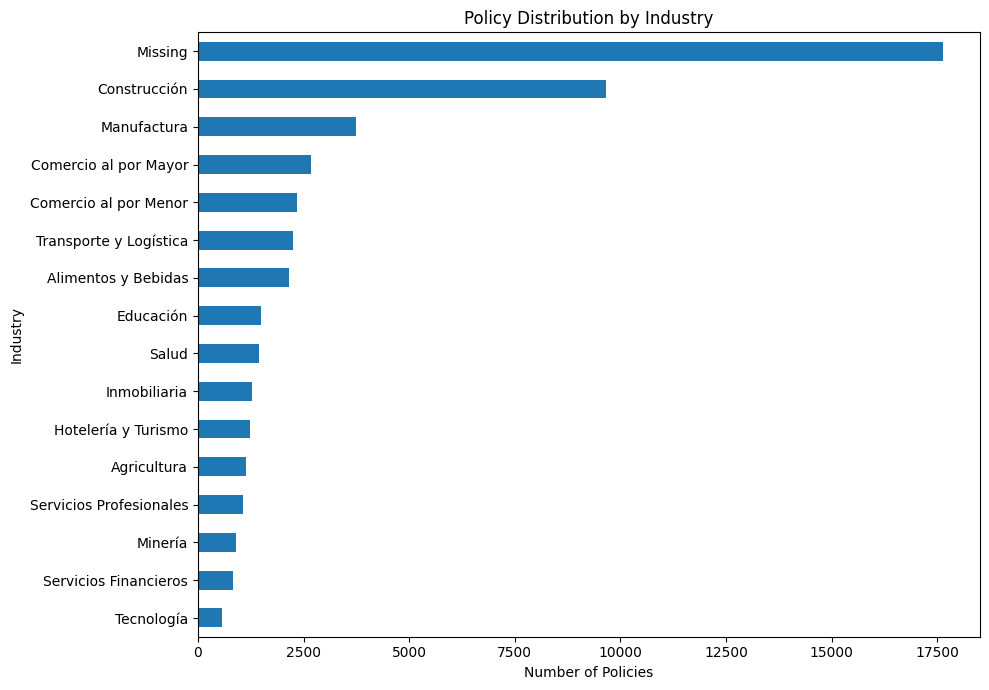

In [26]:
industry_counts = (
    df["industry"]
    .fillna("Missing")
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 7))

industry_counts.plot(kind="barh")

plt.title("Policy Distribution by Industry")
plt.xlabel("Number of Policies")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

### Industry distribution

The labeled portion of the portfolio contains 15 industry categories.

The target is imbalanced, with Construction representing the largest labeled
industry while categories such as Technology have considerably fewer records.

## Client-level industry consistency

Industry represents an attribute of the insured client rather than an individual
policy. Therefore, if the same `ClientId` appears across multiple policies,
known industry labels may provide a reliable way to recover missing labels.

Before applying this strategy, industry consistency must be validated across
existing labeled records.

In [27]:
known_industry = df.dropna(subset=["industry"])

client_industry_count = (
    known_industry
    .groupby("ClientId")["industry"]
    .nunique()
)

conflicting_clients = client_industry_count[
    client_industry_count > 1
]

print(
    f"Clients with conflicting known industries: "
    f"{len(conflicting_clients):,}"
)

Clients with conflicting known industries: 0


In [28]:
client_industry_map = (
    known_industry
    .groupby("ClientId")["industry"]
    .first()
)

missing_mask = df["industry"].isna()

recoverable_mask = (
    missing_mask
    & df["ClientId"].isin(client_industry_map.index)
)

n_missing = missing_mask.sum()
n_recoverable = recoverable_mask.sum()
n_unresolved = n_missing - n_recoverable

print(f"Missing industry records: {n_missing:,}")
print(f"Recoverable using ClientId: {n_recoverable:,}")
print(f"Still unresolved: {n_unresolved:,}")
print(f"Recovery rate: {n_recoverable / n_missing:.2%}")

Missing industry records: 17,631
Recoverable using ClientId: 16,159
Still unresolved: 1,472
Recovery rate: 91.65%


## EDA Conclusion

The analysis identified 17,631 missing industry labels, representing 34.95% of
the portfolio.

Before applying machine learning, historical information from repeated clients
was evaluated as a deterministic recovery mechanism.

Among clients with known industry information, no `ClientId` was associated
with conflicting industry labels. This supports the use of client history as a
high-confidence classification method.

Using this approach:

- 16,159 missing records can be recovered deterministically.
- 91.65% of all missing industry values can be resolved without predictive modeling.
- 1,472 policies remain unresolved and require additional classification methods.